# 🐼 Pandas in Python — Complete Guide from Basic to Advanced

This notebook is a **comprehensive, code-first Pandas course** for Python data analysis and data science.

It follows the progression of the supplied **Pandas from basic to advanced** reference material: introduction and versioning, Series, DataFrames, visualization, indexing, filtering, sorting, statistics, concatenation/merging, GroupBy, missing-data handling, MultiIndex, strings, date/time, and CSV/Excel file handling. The supplied reference identifies Pandas as a library for tabular-data manipulation, cleaning, aggregation, and visualization, with the DataFrame as its central two-dimensional structure. fileciteturn4file0L108-L117

The notebook then expands those topics with additional practical material useful in analytics workflows: data types, copy/view behavior, method chaining, reshaping, `merge`, `join`, `pivot`, `melt`, categorical data, `apply`/`map`, window operations, validation, memory usage, reproducibility, and end-to-end mini projects.

**Design rule:** keep theory in Markdown cells and executable examples in separate Python cells, so each code cell can be run independently after the setup cell.

## 📑 Table of Contents

1. Pandas overview and setup  
2. Series fundamentals  
3. Index objects and labels  
4. DataFrame fundamentals and creation  
5. Inspecting and understanding data  
6. Selecting columns, rows, `loc`, and `iloc`  
7. Filtering and conditional selection  
8. Adding, modifying, renaming, and deleting data  
9. Sorting and ranking  
10. Descriptive statistics and aggregation  
11. Arithmetic, vectorization, `apply`, `map`, and `assign`  
12. Missing data  
13. Duplicates and data cleaning  
14. String operations  
15. Categorical data  
16. GroupBy and split-apply-combine  
17. Combining DataFrames: concat, merge, join  
18. Reshaping: pivot, pivot_table, melt, stack, unstack  
19. MultiIndex and hierarchical data  
20. Date and time  
21. Rolling, expanding, and exponentially weighted windows  
22. Visualization with Pandas  
23. Reading CSV, TSV, Excel, JSON, and other sources  
24. Writing/exporting data  
25. Advanced CSV reading and data-ingestion patterns  
26. Data types, memory, and performance  
27. Method chaining and production-style workflows  
28. Validation, reproducibility, and common pitfalls  
29. End-to-end analytics projects  
30. Exercises and quick reference

# 1️⃣ Pandas Overview & Setup

Pandas is designed for tabular data manipulation, cleaning, aggregation, and visualization. The supplied reference centers on `Series` and `DataFrame` and uses Pandas 2.1.4 as its original demonstration version. fileciteturn4file0L121-L128

### Import Pandas

The conventional import alias is `pd`.

In [1]:
import pandas as pd
import numpy as np
print('pandas:', pd.__version__)
print('numpy :', np.__version__)

pandas: 3.0.5
numpy : 2.5.3


### Version awareness

APIs can evolve. Checking versions is useful when sharing notebooks and reproducing results.

In [2]:
print(pd.__version__)

3.0.5


### Create a local practice workspace

All file examples use a local directory so the notebook does not depend on internet access or external datasets.

In [3]:
from pathlib import Path

BASE = Path.cwd() / '.pandas_lab'
DATA = BASE / 'data'
RAW = DATA / 'raw'
PROCESSED = DATA / 'processed'
OUTPUT = BASE / 'output'
LOGS = BASE / 'logs'
for p in [RAW, PROCESSED, OUTPUT, LOGS]:
    p.mkdir(parents=True, exist_ok=True)
print('Workspace:', BASE.resolve())

Workspace: E:\Data Engineering\DE\Data-Engineering\Python For Data Engineering\Intermediate - 8\.pandas_lab


### Create practice CSV data

This small dataset is reused across many examples.

In [4]:
sales_csv = """order_id,order_date,customer,city,category,product,quantity,unit_price,discount,payment
1001,2026-01-03,Asha,Delhi,Electronics,Mouse,2,900,0.05,Card
1002,2026-01-04,Ravi,Mumbai,Office,Notebook,5,120,0.00,UPI
1003,2026-01-05,Neha,Delhi,Electronics,Keyboard,1,1800,0.10,Card
1004,2026-01-07,Amit,Bengaluru,Office,Pen,20,25,0.02,Cash
1005,2026-01-09,Riya,Chennai,Electronics,Monitor,2,12500,0.08,UPI
1006,2026-01-10,Karan,Mumbai,Office,Notebook,3,120,,UPI
1007,2026-01-12,Sana,Chennai,Home,Lamp,4,850,0.15,Card
1008,2026-01-15,Vikram,Delhi,Home,Chair,2,4500,0.05,Card
1009,2026-01-18,Meera,Bengaluru,Electronics,Mouse,3,900,0.00,UPI
1010,2026-01-21,Arun,Mumbai,Office,Desk,1,7000,0.05,Cash
"""
(RAW/'sales.csv').write_text(sales_csv, encoding='utf-8')

customers_csv = """customer_id,customer,city,segment
C001,Asha,Delhi,Consumer
C002,Ravi,Mumbai,Corporate
C003,Neha,Delhi,Consumer
C004,Amit,Bengaluru,Corporate
C005,Riya,Chennai,Consumer
C006,Karan,Mumbai,Consumer
"""
(RAW/'customers.csv').write_text(customers_csv, encoding='utf-8')

print('Created:', (RAW/'sales.csv').resolve())
print('Created:', (RAW/'customers.csv').resolve())

Created: E:\Data Engineering\DE\Data-Engineering\Python For Data Engineering\Intermediate - 8\.pandas_lab\data\raw\sales.csv
Created: E:\Data Engineering\DE\Data-Engineering\Python For Data Engineering\Intermediate - 8\.pandas_lab\data\raw\customers.csv


# 2️⃣ Series Fundamentals

A `Series` is a one-dimensional labeled array. The reference introduces creation, information about values and index, slicing, and custom indexes. fileciteturn4file0L129-L145

### Create a Series

A Series can be created from lists, tuples, NumPy arrays, dictionaries, and scalars.

In [5]:
s = pd.Series([10, 20, 30, 40])
print(s)

0    10
1    20
2    30
3    40
dtype: int64


### Series from a dictionary

Dictionary keys become the index labels.

In [6]:
s = pd.Series({'Math': 82, 'Physics': 91, 'Python': 95})
print(s)

Math       82
Physics    91
Python     95
dtype: int64


### Series with a custom index

The number of labels should match the number of values.

In [7]:
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(s)

a    10
b    20
c    30
dtype: int64


### Series attributes

Important attributes include `values`, `index`, `dtype`, `name`, and `shape`.

In [8]:
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'], name='score')
print('values:', s.values)
print('index :', s.index)
print('dtype :', s.dtype)
print('name  :', s.name)
print('shape :', s.shape)

values: [10 20 30]
index : Index(['a', 'b', 'c'], dtype='str')
dtype : int64
name  : score
shape : (3,)


### Series slicing

The familiar slice form is `start:stop:step`; positional behavior is best made explicit with `iloc`.

In [9]:
s = pd.Series([0.25, 0.50, 0.75, 1.00])
print(s[1:3])
print(s.iloc[1:3])
print(s.iloc[::2])

1    0.50
2    0.75
dtype: float64
1    0.50
2    0.75
dtype: float64
0    0.25
2    0.75
dtype: float64


### Label-based access

When an index has meaningful labels, `loc` makes intent explicit.

In [10]:
s = pd.Series([100, 200, 300], index=['a', 'b', 'c'])
print(s.loc['b'])
print(s.loc['a':'b'])

200
a    100
b    200
dtype: int64


### Boolean selection on Series

A boolean mask can select values that meet a condition.

In [11]:
s = pd.Series([12, 5, 19, 8, 25])
mask = s >= 10
print(mask)
print(s[mask])

0     True
1    False
2     True
3    False
4     True
dtype: bool
0    12
2    19
4    25
dtype: int64


### Series vectorized arithmetic

Operations are element-wise and preserve the index.

In [12]:
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(s * 2)
print(s + 5)
print(s ** 2)

a    20
b    40
c    60
dtype: int64
a    15
b    25
c    35
dtype: int64
a    100
b    400
c    900
dtype: int64


### Series alignment

Pandas aligns labels before arithmetic; this is one of its most important differences from plain NumPy arrays.

In [13]:
a = pd.Series({'x': 10, 'y': 20})
b = pd.Series({'y': 3, 'z': 5})
print(a + b)

x     NaN
y    23.0
z     NaN
dtype: float64


### Descriptive statistics

The reference highlights `describe()` and `agg()` for statistical summaries. fileciteturn4file0L161-L184

In [14]:
s = pd.Series([3, 6, 9, 8, 5, 4, 2, 6, 3, 5, 8])
print(s.describe())
print(s.agg(['max', 'min', 'sum', 'mean', 'std']))

count    11.000000
mean      5.363636
std       2.292280
min       2.000000
25%       3.500000
50%       5.000000
75%       7.000000
max       9.000000
dtype: float64
max      9.000000
min      2.000000
sum     59.000000
mean     5.363636
std      2.292280
dtype: float64


# 3️⃣ Index Objects & Labels

Pandas labels are first-class objects. The reference also demonstrates `pd.Index` for label collections. fileciteturn4file0L242-L260

### Create an Index

An Index is an immutable container of labels used by Series and DataFrames.

In [15]:
idx = pd.Index([10, 20, 30])
print(idx)
print('type:', type(idx))

Index([10, 20, 30], dtype='int64')
type: <class 'pandas.Index'>


### Index properties

Inspect labels using properties and methods.

In [16]:
idx = pd.Index(['Delhi', 'Mumbai', 'Chennai'])
print('values:', idx.values)
print('size:', idx.size)
print('dtype:', idx.dtype)
print('is_unique:', idx.is_unique)

values: <StringArray>
['Delhi', 'Mumbai', 'Chennai']
Length: 3, dtype: str
size: 3
dtype: str
is_unique: True


### Set operations on Index

Index objects support set-like operations such as intersection and union.

In [17]:
a = pd.Index([1, 3, 5, 7])
b = pd.Index([3, 5, 7, 9])
print('intersection:', a.intersection(b))
print('union       :', a.union(b))
print('difference  :', a.difference(b))

intersection: Index([3, 5, 7], dtype='int64')
union       : Index([1, 3, 5, 7, 9], dtype='int64')
difference  : Index([1], dtype='int64')


# 4️⃣ DataFrame Fundamentals

A DataFrame is Pandas' central two-dimensional tabular object. The supplied reference shows creation from arrays, lists, Series, dictionaries, and generated records. fileciteturn4file0L342-L352

### Create from a dictionary

Each dictionary key becomes a column.

In [18]:
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 28],
    'Occupation': ['Engineer', 'Data Scientist', 'Designer']
})
print(df)

      Name  Age      Occupation
0    Alice   25        Engineer
1      Bob   30  Data Scientist
2  Charlie   28        Designer


### Create from a list of lists

Supply column labels to make the table readable.

In [19]:
rows = [['Alice', 25], ['Bob', 30], ['Charlie', 28]]
df = pd.DataFrame(rows, columns=['Name', 'Age'])
print(df)

      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   28


### Create from NumPy array

Array dimensions must match the number of row and column labels.

In [20]:
arr = np.array([[6, 9, 8], [0, 2, 5], [8, 5, 4]])
df = pd.DataFrame(arr, index=['a', 'b', 'c'], columns=['one', 'two', 'three'])
print(df)

   one  two  three
a    6    9      8
b    0    2      5
c    8    5      4


### Create from multiple Series

Series with matching indexes align naturally into DataFrame columns.

In [21]:
w = pd.Series({'a': 1, 'b': 2, 'c': 3})
x = pd.Series({'a': 4, 'b': 5, 'c': 6})
df = pd.DataFrame({'Math': w, 'Physics': x})
print(df)

   Math  Physics
a     1        4
b     2        5
c     3        6


### Create from list of dictionaries

Missing keys are filled with missing values.

In [22]:
df = pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}, {'d': 5, 'e': 6}])
print(df)

     a    b    c    d    e
0  1.0  2.0  NaN  NaN  NaN
1  NaN  3.0  4.0  NaN  NaN
2  NaN  NaN  NaN  5.0  6.0


### Create with a function

Functions help generate repeatable example tables.

In [23]:
def make_df(cols, ind):
    data = {c: [f'{c}{i}' for i in ind] for c in cols}
    return pd.DataFrame(data, index=ind)
print(make_df('ABC', range(3)))

    A   B   C
0  A0  B0  C0
1  A1  B1  C1
2  A2  B2  C2


### DataFrame shape and axes

The `shape`, `index`, and `columns` attributes describe table structure.

In [24]:
df = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
print('shape:', df.shape)
print('index:', df.index)
print('columns:', df.columns)

shape: (2, 2)
index: RangeIndex(start=0, stop=2, step=1)
columns: Index(['A', 'B'], dtype='str')


### Transpose

`.T` swaps rows and columns, matching the supplied reference.

In [25]:
df = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
print(df.T)

   0  1
A  1  2
B  3  4


# 5️⃣ Inspecting & Understanding Data

Before analysis, inspect shape, types, missing values, duplicates, and summary statistics.

### Load the main sales dataset

`read_csv` loads tabular text into a DataFrame.

In [26]:
sales = pd.read_csv(RAW / 'sales.csv')
print(sales.head())

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
3          25      0.02    Cash  
4       12500      0.08     UPI  


### Head and tail

`head()` and `tail()` quickly inspect records.

In [27]:
print(sales.head(3))
print(sales.tail(3))

   order_id  order_date customer    city     category   product  quantity  \
0      1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi  Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha   Delhi  Electronics  Keyboard         1   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
   order_id  order_date customer       city     category product  quantity  \
7      1008  2026-01-15   Vikram      Delhi         Home   Chair         2   
8      1009  2026-01-18    Meera  Bengaluru  Electronics   Mouse         3   
9      1010  2026-01-21     Arun     Mumbai       Office    Desk         1   

   unit_price  discount payment  
7        4500      0.05    Card  
8         900      0.00     UPI  
9        7000      0.05    Cash  


### Sample rows

`sample()` is useful for spot-checking random records.

In [28]:
print(sales.sample(4, random_state=42))

   order_id  order_date customer       city     category   product  quantity  \
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
5      1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   

   unit_price  discount payment  
8         900      0.00     UPI  
1         120      0.00     UPI  
5         120       NaN     UPI  
0         900      0.05    Card  


### Info

`info()` shows row counts, non-null counts, data types, and memory usage.

In [29]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    10 non-null     int64  
 1   order_date  10 non-null     str    
 2   customer    10 non-null     str    
 3   city        10 non-null     str    
 4   category    10 non-null     str    
 5   product     10 non-null     str    
 6   quantity    10 non-null     int64  
 7   unit_price  10 non-null     int64  
 8   discount    9 non-null      float64
 9   payment     10 non-null     str    
dtypes: float64(1), int64(3), str(6)
memory usage: 932.0 bytes


### Describe numeric columns

`describe()` provides count, mean, std, quartiles, min, and max for numeric columns.

In [30]:
print(sales.describe())

         order_id   quantity    unit_price  discount
count    10.00000  10.000000     10.000000  9.000000
mean   1005.50000   4.300000   2871.500000  0.055556
std       3.02765   5.657836   4064.163198  0.048762
min    1001.00000   1.000000     25.000000  0.000000
25%    1003.25000   2.000000    302.500000  0.020000
50%    1005.50000   2.500000    900.000000  0.050000
75%    1007.75000   3.750000   3825.000000  0.080000
max    1010.00000  20.000000  12500.000000  0.150000


### Describe all columns

Use `include='all'` when categorical information matters.

In [31]:
print(sales.describe(include='all').T)

           count unique          top freq      mean          std     min  \
order_id    10.0    NaN          NaN  NaN    1005.5      3.02765  1001.0   
order_date    10     10   2026-01-03    1       NaN          NaN     NaN   
customer      10     10         Asha    1       NaN          NaN     NaN   
city          10      4        Delhi    3       NaN          NaN     NaN   
category      10      3  Electronics    4       NaN          NaN     NaN   
product       10      8        Mouse    2       NaN          NaN     NaN   
quantity    10.0    NaN          NaN  NaN       4.3     5.657836     1.0   
unit_price  10.0    NaN          NaN  NaN    2871.5  4064.163198    25.0   
discount     9.0    NaN          NaN  NaN  0.055556     0.048762     0.0   
payment       10      3         Card    4       NaN          NaN     NaN   

                25%     50%      75%      max  
order_id    1003.25  1005.5  1007.75   1010.0  
order_date      NaN     NaN      NaN      NaN  
customer        NaN

### Data types

Use `dtypes` to inspect inferred column types.

In [32]:
print(sales.dtypes)

order_id        int64
order_date        str
customer          str
city              str
category          str
product           str
quantity        int64
unit_price      int64
discount      float64
payment           str
dtype: object


### Memory usage

`memory_usage(deep=True)` gives more realistic memory estimates for object/string data.

In [33]:
mem = sales.memory_usage(deep=True)
print(mem)
print('total bytes:', mem.sum())

Index         132
order_id       80
order_date    590
customer      534
city          555
category      566
product       547
quantity       80
unit_price     80
discount       80
payment       526
dtype: int64
total bytes: 3770


### Unique values and counts

`nunique`, `unique`, and `value_counts` are core exploratory tools.

In [34]:
print('cities:', sales['city'].unique())
print('city counts:\n', sales['city'].value_counts())
print('unique categories:', sales['category'].nunique())

cities: <StringArray>
['Delhi', 'Mumbai', 'Bengaluru', 'Chennai']
Length: 4, dtype: str
city counts:
 city
Delhi        3
Mumbai       3
Bengaluru    2
Chennai      2
Name: count, dtype: int64
unique categories: 3


# 6️⃣ Selecting Columns, Rows, loc & iloc

The supplied reference distinguishes positional `iloc` from label-based `loc`, including conditional selection. fileciteturn4file0L631-L641

### Select one column

A single column is returned as a Series.

In [35]:
print(sales['customer'])

0      Asha
1      Ravi
2      Neha
3      Amit
4      Riya
5     Karan
6      Sana
7    Vikram
8     Meera
9      Arun
Name: customer, dtype: str


### Select multiple columns

Pass a list of column names.

In [36]:
print(sales[['customer', 'city', 'category']])

  customer       city     category
0     Asha      Delhi  Electronics
1     Ravi     Mumbai       Office
2     Neha      Delhi  Electronics
3     Amit  Bengaluru       Office
4     Riya    Chennai  Electronics
5    Karan     Mumbai       Office
6     Sana    Chennai         Home
7   Vikram      Delhi         Home
8    Meera  Bengaluru  Electronics
9     Arun     Mumbai       Office


### Select rows by position with iloc

`iloc` is integer-position based.

In [37]:
print(sales.iloc[0])
print(sales.iloc[0:3, 0:4])

order_id             1001
order_date     2026-01-03
customer             Asha
city                Delhi
category      Electronics
product             Mouse
quantity                2
unit_price            900
discount             0.05
payment              Card
Name: 0, dtype: object
   order_id  order_date customer    city
0      1001  2026-01-03     Asha   Delhi
1      1002  2026-01-04     Ravi  Mumbai
2      1003  2026-01-05     Neha   Delhi


### Select rows/columns with loc

`loc` uses labels; slices on labels are inclusive when labels are sorted/unique as expected.

In [38]:
sales2 = sales.set_index('order_id')
print(sales2.loc[[1001, 1003], ['customer', 'city', 'quantity']])

         customer   city  quantity
order_id                          
1001         Asha  Delhi         2
1003         Neha  Delhi         1


### Conditional loc

Boolean conditions can be combined with `loc` to select rows and columns.

In [39]:
result = sales.loc[sales['quantity'] >= 3, ['order_id', 'product', 'quantity']]
print(result)

   order_id   product  quantity
1      1002  Notebook         5
3      1004       Pen        20
5      1006  Notebook         3
6      1007      Lamp         4
8      1009     Mouse         3


### Set an index

The reference uses `set_index` to turn a column into the index.

In [40]:
tmp = sales.copy()
tmp = tmp.set_index('order_id')
print(tmp.head())

          order_date customer       city     category   product  quantity  \
order_id                                                                    
1001      2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1002      2026-01-04     Ravi     Mumbai       Office  Notebook         5   
1003      2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
1004      2026-01-07     Amit  Bengaluru       Office       Pen        20   
1005      2026-01-09     Riya    Chennai  Electronics   Monitor         2   

          unit_price  discount payment  
order_id                                
1001             900      0.05    Card  
1002             120      0.00     UPI  
1003            1800      0.10    Card  
1004              25      0.02    Cash  
1005           12500      0.08     UPI  


### Reset an index

`reset_index()` moves the index back into columns.

In [41]:
tmp = sales.set_index('order_id')
print(tmp.reset_index().head())

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
3          25      0.02    Cash  
4       12500      0.08     UPI  


# 7️⃣ Filtering & Conditional Selection

Use boolean masks, `query`, `isin`, `between`, `str.contains`, and combinations of conditions.

### Simple condition

A boolean Series can be used directly as a row filter.

In [42]:
print(sales[sales['city'] == 'Delhi'])

   order_id  order_date customer   city     category   product  quantity  \
0      1001  2026-01-03     Asha  Delhi  Electronics     Mouse         2   
2      1003  2026-01-05     Neha  Delhi  Electronics  Keyboard         1   
7      1008  2026-01-15   Vikram  Delhi         Home     Chair         2   

   unit_price  discount payment  
0         900      0.05    Card  
2        1800      0.10    Card  
7        4500      0.05    Card  


### Multiple AND conditions

Use `&` with parentheses around each condition.

In [43]:
result = sales[(sales['city'] == 'Delhi') & (sales['quantity'] >= 2)]
print(result)

   order_id  order_date customer   city     category product  quantity  \
0      1001  2026-01-03     Asha  Delhi  Electronics   Mouse         2   
7      1008  2026-01-15   Vikram  Delhi         Home   Chair         2   

   unit_price  discount payment  
0         900      0.05    Card  
7        4500      0.05    Card  


### Multiple OR conditions

Use `|` for logical OR.

In [44]:
result = sales[(sales['city'] == 'Delhi') | (sales['city'] == 'Chennai')]
print(result)

   order_id  order_date customer     city     category   product  quantity  \
0      1001  2026-01-03     Asha    Delhi  Electronics     Mouse         2   
2      1003  2026-01-05     Neha    Delhi  Electronics  Keyboard         1   
4      1005  2026-01-09     Riya  Chennai  Electronics   Monitor         2   
6      1007  2026-01-12     Sana  Chennai         Home      Lamp         4   
7      1008  2026-01-15   Vikram    Delhi         Home     Chair         2   

   unit_price  discount payment  
0         900      0.05    Card  
2        1800      0.10    Card  
4       12500      0.08     UPI  
6         850      0.15    Card  
7        4500      0.05    Card  


### NOT condition

Use `~` to negate a boolean mask.

In [45]:
print(sales[~sales['payment'].eq('Cash')])

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   
5      1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   
6      1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
7      1008  2026-01-15   Vikram      Delhi         Home     Chair         2   
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
4       12500      0.08     UPI  
5         120       NaN     UPI  
6         850      0.15    Card  
7        4500      0.05    Card  
8      

### isin

`isin` is cleaner than chaining many OR conditions.

In [46]:
print(sales[sales['city'].isin(['Delhi', 'Mumbai'])])

   order_id  order_date customer    city     category   product  quantity  \
0      1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi  Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha   Delhi  Electronics  Keyboard         1   
5      1006  2026-01-10    Karan  Mumbai       Office  Notebook         3   
7      1008  2026-01-15   Vikram   Delhi         Home     Chair         2   
9      1010  2026-01-21     Arun  Mumbai       Office      Desk         1   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
5         120       NaN     UPI  
7        4500      0.05    Card  
9        7000      0.05    Cash  


### between

`between` selects values inside a numeric or date range.

In [47]:
print(sales[sales['unit_price'].between(500, 5000)])

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
6      1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
7      1008  2026-01-15   Vikram      Delhi         Home     Chair         2   
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   

   unit_price  discount payment  
0         900      0.05    Card  
2        1800      0.10    Card  
6         850      0.15    Card  
7        4500      0.05    Card  
8         900      0.00     UPI  


### query

`query` expresses row conditions as a readable string.

In [48]:
print(sales.query("city == 'Delhi' and quantity >= 2"))

   order_id  order_date customer   city     category product  quantity  \
0      1001  2026-01-03     Asha  Delhi  Electronics   Mouse         2   
7      1008  2026-01-15   Vikram  Delhi         Home   Chair         2   

   unit_price  discount payment  
0         900      0.05    Card  
7        4500      0.05    Card  


### query with external variable

Use `@name` inside a query expression for Python variables.

In [49]:
min_qty = 3
print(sales.query('quantity >= @min_qty'))

   order_id  order_date customer       city     category   product  quantity  \
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
5      1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   
6      1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   

   unit_price  discount payment  
1         120      0.00     UPI  
3          25      0.02    Cash  
5         120       NaN     UPI  
6         850      0.15    Card  
8         900      0.00     UPI  


# 8️⃣ Adding, Modifying, Renaming & Deleting

DataFrames are mutable objects, but explicit assignment and `assign` make transformations easier to reason about.

### Add a column

Assign a Series or expression to a new column.

In [50]:
df = sales[['order_id', 'quantity', 'unit_price']].copy()
df['gross'] = df['quantity'] * df['unit_price']
print(df)

   order_id  quantity  unit_price  gross
0      1001         2         900   1800
1      1002         5         120    600
2      1003         1        1800   1800
3      1004        20          25    500
4      1005         2       12500  25000
5      1006         3         120    360
6      1007         4         850   3400
7      1008         2        4500   9000
8      1009         3         900   2700
9      1010         1        7000   7000


### Modify a column

Vectorized arithmetic updates all rows efficiently.

In [51]:
df = sales[['quantity', 'unit_price']].copy()
df['unit_price_with_tax'] = df['unit_price'] * 1.18
print(df.head())

   quantity  unit_price  unit_price_with_tax
0         2         900               1062.0
1         5         120                141.6
2         1        1800               2124.0
3        20          25                 29.5
4         2       12500              14750.0


### Rename columns

Use `rename(columns={...})` for targeted renaming.

In [52]:
df = sales.rename(columns={'unit_price': 'price', 'order_date': 'date'})
print(df.columns.tolist())

['order_id', 'date', 'customer', 'city', 'category', 'product', 'quantity', 'price', 'discount', 'payment']


### Rename all columns

Assign a complete list when every name should change.

In [53]:
df = pd.DataFrame([[1, 2], [3, 4]], columns=['A', 'B'])
df.columns = ['first', 'second']
print(df)

   first  second
0      1       2
1      3       4


### Drop a column

`drop(columns=[...])` removes unwanted columns.

In [54]:
df = sales.drop(columns=['discount'])
print(df.columns.tolist())

['order_id', 'order_date', 'customer', 'city', 'category', 'product', 'quantity', 'unit_price', 'payment']


### Drop rows

`drop(index=[...])` removes rows by index label.

In [55]:
df = pd.DataFrame({'A': [10, 20, 30]}, index=['x', 'y', 'z'])
print(df.drop(index=['y']))

    A
x  10
z  30


### Insert a column

`insert` gives control over column position.

In [56]:
df = sales[['order_id', 'quantity', 'unit_price']].copy()
df.insert(2, 'gross', df['quantity'] * df['unit_price'])
print(df.head())

   order_id  quantity  gross  unit_price
0      1001         2   1800         900
1      1002         5    600         120
2      1003         1   1800        1800
3      1004        20    500          25
4      1005         2  25000       12500


### assign

`assign` returns a new DataFrame and works well with method chaining.

In [57]:
result = (sales[['order_id', 'quantity', 'unit_price']]
          .assign(gross=lambda x: x['quantity'] * x['unit_price']))
print(result.head())

   order_id  quantity  unit_price  gross
0      1001         2         900   1800
1      1002         5         120    600
2      1003         1        1800   1800
3      1004        20          25    500
4      1005         2       12500  25000


# 9️⃣ Sorting & Ranking

The reference demonstrates sorting rows by selected columns and choosing ascending or descending order. fileciteturn4file0L750-L772

### Sort by one column

Use `sort_values`.

In [58]:
print(sales.sort_values('unit_price'))

   order_id  order_date customer       city     category   product  quantity  \
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
5      1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   
6      1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
7      1008  2026-01-15   Vikram      Delhi         Home     Chair         2   
9      1010  2026-01-21     Arun     Mumbai       Office      Desk         1   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  
3          25      0.02    Cash  
1         120      0.00     UPI  
5         120    

### Descending sort

Set `ascending=False`.

In [59]:
print(sales.sort_values('unit_price', ascending=False).head())

   order_id  order_date customer       city     category   product  quantity  \
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   
9      1010  2026-01-21     Arun     Mumbai       Office      Desk         1   
7      1008  2026-01-15   Vikram      Delhi         Home     Chair         2   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   

   unit_price  discount payment  
4       12500      0.08     UPI  
9        7000      0.05    Cash  
7        4500      0.05    Card  
2        1800      0.10    Card  
8         900      0.00     UPI  


### Sort by multiple columns

Provide a list and a matching `ascending` list.

In [60]:
print(sales.sort_values(['city', 'unit_price'], ascending=[True, False]).head(10))

   order_id  order_date customer       city     category   product  quantity  \
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   
6      1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
7      1008  2026-01-15   Vikram      Delhi         Home     Chair         2   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
9      1010  2026-01-21     Arun     Mumbai       Office      Desk         1   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
5      1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   

   unit_price  discount payment  
8         900      0.00     UPI  
3          25      0.02    Cash  
4       12500    

### Sort by index

`sort_index` orders labels rather than values.

In [61]:
tmp = sales.set_index('order_id')
print(tmp.sort_index().head())

          order_date customer       city     category   product  quantity  \
order_id                                                                    
1001      2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1002      2026-01-04     Ravi     Mumbai       Office  Notebook         5   
1003      2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
1004      2026-01-07     Amit  Bengaluru       Office       Pen        20   
1005      2026-01-09     Riya    Chennai  Electronics   Monitor         2   

          unit_price  discount payment  
order_id                                
1001             900      0.05    Card  
1002             120      0.00     UPI  
1003            1800      0.10    Card  
1004              25      0.02    Cash  
1005           12500      0.08     UPI  


### Rank values

`rank` calculates ordinal positions and supports different tie methods.

In [62]:
s = pd.Series([100, 80, 100, 90])
print(s.rank(method='dense', ascending=False))

0    1.0
1    3.0
2    1.0
3    2.0
dtype: float64


# 🔟 Statistics, Aggregation & Correlation

The supplied reference covers max/min/mean/std, correlation, skewness, arithmetic between columns, and `describe`. fileciteturn4file0L773-L879

### Column statistics

Series expose common statistical methods directly.

In [63]:
s = sales['unit_price']
print('max:', s.max())
print('min:', s.min())
print('mean:', s.mean())
print('std:', s.std())

max: 12500
min: 25
mean: 2871.5
std: 4064.1631980027573


### DataFrame column-wise statistics

Most reductions operate column-wise by default.

In [64]:
print(sales[['quantity', 'unit_price']].agg(['min', 'max', 'mean', 'sum']))

      quantity  unit_price
min        1.0        25.0
max       20.0     12500.0
mean       4.3      2871.5
sum       43.0     28715.0


### Row-wise statistics

Use `axis=1` when calculating across columns within each row.

In [65]:
df = sales[['quantity', 'unit_price']].copy()
print(df.mean(axis=1).head())

0     451.0
1      62.5
2     900.5
3      22.5
4    6251.0
dtype: float64


### Correlation

`corr()` measures pairwise correlation for numeric columns.

In [66]:
print(sales[['quantity', 'unit_price']].corr())

            quantity  unit_price
quantity    1.000000   -0.344599
unit_price -0.344599    1.000000


### Skewness

`skew()` summarizes asymmetry of numeric distributions.

In [67]:
print(sales[['quantity', 'unit_price']].skew())

quantity      2.881432
unit_price    1.816108
dtype: float64


### Value counts normalized

Set `normalize=True` to obtain proportions.

In [68]:
print(sales['category'].value_counts(normalize=True))

category
Electronics    0.4
Office         0.4
Home           0.2
Name: proportion, dtype: float64


### Custom aggregation

`agg` accepts a list of functions or named aggregations.

In [69]:
print(sales.groupby('city')['unit_price'].agg(['count', 'mean', 'min', 'max']))

           count         mean  min    max
city                                     
Bengaluru      2   462.500000   25    900
Chennai        2  6675.000000  850  12500
Delhi          3  2400.000000  900   4500
Mumbai         3  2413.333333  120   7000


# 1️⃣1️⃣ Vectorization, map, apply, applymap Alternatives & eval

Prefer vectorized Pandas operations where possible. `apply` is useful when no suitable vectorized expression exists.

### Vectorized arithmetic

Column arithmetic is fast and readable.

In [70]:
df = sales[['quantity', 'unit_price']].copy()
df['gross'] = df['quantity'] * df['unit_price']
print(df.head())

   quantity  unit_price  gross
0         2         900   1800
1         5         120    600
2         1        1800   1800
3        20          25    500
4         2       12500  25000


### Series map

`map` transforms each element of a Series.

In [71]:
sales2 = sales.copy()
sales2['payment_code'] = sales2['payment'].map({'Card': 1, 'UPI': 2, 'Cash': 3})
print(sales2[['payment', 'payment_code']].drop_duplicates())

  payment  payment_code
0    Card             1
1     UPI             2
3    Cash             3


### Series apply

`apply` can call a Python function element-by-element.

In [72]:
s = pd.Series(['Delhi', 'Mumbai', 'Chennai'])
print(s.apply(str.upper))

0      DELHI
1     MUMBAI
2    CHENNAI
dtype: str


### DataFrame apply by column

With `axis=0`, the function receives each column as a Series.

In [73]:
df = sales[['quantity', 'unit_price']]
print(df.apply(lambda col: col.max() - col.min()))

quantity         19
unit_price    12475
dtype: int64


### DataFrame apply by row

With `axis=1`, the function receives each row as a Series.

In [74]:
df = sales[['quantity', 'unit_price']].copy()
print(df.apply(lambda row: row['quantity'] * row['unit_price'], axis=1).head())

0     1800
1      600
2     1800
3      500
4    25000
dtype: int64


### pd.eval

The supplied reference also introduces expression-based evaluation for arithmetic.

In [75]:
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6], 'C': [2, 2, 2]})
print(pd.eval('(df.A + df.B) / df.C'))

0    2.5
1    3.5
2    4.5
dtype: float64


# 1️⃣2️⃣ Missing Data

The reference explicitly covers detecting and removing missing data, and transforming missing representations. fileciteturn4file0L64-L71

### Detect missing values

`isna()` and `isnull()` identify missing entries.

In [76]:
tmp = sales.copy()
print(tmp.isna().sum())

order_id      0
order_date    0
customer      0
city          0
category      0
product       0
quantity      0
unit_price    0
discount      1
payment       0
dtype: int64


### Missing percentage

Null counts become more useful when expressed as a percentage of rows.

In [77]:
null_pct = sales.isna().mean().mul(100).sort_values(ascending=False)
print(null_pct)

discount      10.0
order_id       0.0
order_date     0.0
customer       0.0
category       0.0
city           0.0
product        0.0
quantity       0.0
unit_price     0.0
payment        0.0
dtype: float64


### Rows containing missing values

`dropna()` can remove rows with missing data.

In [78]:
tmp = sales.dropna()
print('before:', len(sales), 'after:', len(tmp))

before: 10 after: 9


### Drop rows only when specific columns are missing

Use `subset` to narrow the decision.

In [79]:
tmp = sales.dropna(subset=['payment', 'discount'])
print(tmp[['order_id', 'payment', 'discount']])

   order_id payment  discount
0      1001    Card      0.05
1      1002     UPI      0.00
2      1003    Card      0.10
3      1004    Cash      0.02
4      1005     UPI      0.08
6      1007    Card      0.15
7      1008    Card      0.05
8      1009     UPI      0.00
9      1010    Cash      0.05


### Fill missing values

`fillna` replaces missing entries with a chosen value.

In [80]:
tmp = sales.copy()
tmp['discount'] = tmp['discount'].fillna(0)
print(tmp[['order_id', 'discount']])

   order_id  discount
0      1001      0.05
1      1002      0.00
2      1003      0.10
3      1004      0.02
4      1005      0.08
5      1006      0.00
6      1007      0.15
7      1008      0.05
8      1009      0.00
9      1010      0.05


### Forward fill and backward fill

These are useful for ordered/time-series data where carrying values forward/backward is meaningful.

In [81]:
s = pd.Series([10, np.nan, np.nan, 40])
print('ffill:', s.ffill().tolist())
print('bfill:', s.bfill().tolist())

ffill: [10.0, 10.0, 10.0, 40.0]
bfill: [10.0, 40.0, 40.0, 40.0]


### Interpolation

Interpolation estimates intermediate values for numeric sequences.

In [82]:
s = pd.Series([10, np.nan, 30, np.nan, 50])
print(s.interpolate().tolist())

[10.0, 20.0, 30.0, 40.0, 50.0]


### Replace alternate missing markers

Standardize inconsistent missing-value representations before analysis.

In [83]:
s = pd.Series(['10', 'NA', 'N/A', '', '20', None])
clean = s.replace(['NA', 'N/A', ''], np.nan)
print(clean)

0     10
1    NaN
2    NaN
3    NaN
4     20
5    NaN
dtype: str


# 1️⃣3️⃣ Duplicates & Data Cleaning

Cleaning is a workflow: inspect, decide, transform, validate.

### Detect duplicate rows

Use `duplicated()` to identify repeated records.

In [84]:
df = pd.DataFrame({'id': [1, 1, 2], 'value': ['A', 'A', 'B']})
print(df.duplicated())

0    False
1     True
2    False
dtype: bool


### Remove duplicates

`drop_duplicates` keeps the first occurrence by default.

In [85]:
df = pd.DataFrame({'id': [1, 1, 2], 'value': ['A', 'A', 'B']})
print(df.drop_duplicates())

   id value
0   1     A
2   2     B


### Control duplicate criteria

Choose the subset of columns and the retained record.

In [86]:
df = pd.DataFrame({'id': [1, 1, 2], 'value': ['old', 'new', 'B']})
print(df.drop_duplicates(subset=['id'], keep='last'))

   id value
1   1   new
2   2     B


### Normalize text before duplicate detection

Whitespace and case can create false duplicates.

In [87]:
s = pd.Series([' Delhi ', 'delhi', 'DELHI'])
normalized = s.str.strip().str.casefold()
print(normalized)

0    delhi
1    delhi
2    delhi
dtype: str


# 1️⃣4️⃣ String Operations

Pandas provides vectorized string methods through the `.str` accessor.

### String cleanup

Use `str.strip`, `str.lower`, `str.upper`, and `str.title` for normalization.

In [88]:
s = pd.Series(['  Delhi', 'mumbai  ', 'CHENNAI'])
print(s.str.strip().str.title())

0      Delhi
1     Mumbai
2    Chennai
dtype: str


### Contains

`str.contains` is useful for keyword filtering.

In [89]:
print(sales[sales['product'].str.contains('note', case=False, na=False)])

   order_id  order_date customer    city category   product  quantity  \
1      1002  2026-01-04     Ravi  Mumbai   Office  Notebook         5   
5      1006  2026-01-10    Karan  Mumbai   Office  Notebook         3   

   unit_price  discount payment  
1         120       0.0     UPI  
5         120       NaN     UPI  


### Startswith and endswith

Use them for prefix/suffix conditions.

In [90]:
s = sales['product']
print(s[s.str.startswith('M')])
print(s[s.str.endswith('e')])

0      Mouse
4    Monitor
8      Mouse
Name: product, dtype: str
0    Mouse
8    Mouse
Name: product, dtype: str


### Split strings

`str.split` can separate composite text into multiple pieces.

In [91]:
s = pd.Series(['Ravi-Kumar', 'Asha-Singh'])
print(s.str.split('-', expand=True))

      0      1
0  Ravi  Kumar
1  Asha  Singh


### Replace strings

`str.replace` can standardize terminology.

In [92]:
s = pd.Series(['Data Science', 'data science', 'DATA SCIENCE'])
print(s.str.replace('data science', 'Analytics', case=False, regex=False))

0    Analytics
1    Analytics
2    Analytics
dtype: str


### Extract with regex

`str.extract` can capture structured information from text.

In [93]:
s = pd.Series(['Order-1001', 'Order-1002', 'Order-1003'])
print(s.str.extract(r'Order-(\d+)', expand=False))

0    1001
1    1002
2    1003
dtype: str


# 1️⃣5️⃣ Categorical Data

Categoricals are especially useful for repeated low-cardinality labels and explicit category ordering.

### Create a categorical Series

Use `astype('category')` or `pd.Categorical`.

In [94]:
s = pd.Series(['Bronze', 'Silver', 'Gold', 'Gold']).astype('category')
print(s)
print(s.dtype)

0    Bronze
1    Silver
2      Gold
3      Gold
dtype: category
Categories (3, str): ['Bronze', 'Gold', 'Silver']
category


### Categorical codes

Categories have internal codes; the codes are not the original labels.

In [95]:
s = pd.Series(['Bronze', 'Silver', 'Gold', 'Gold']).astype('category')
print('categories:', s.cat.categories.tolist())
print('codes:', s.cat.codes.tolist())

categories: ['Bronze', 'Gold', 'Silver']
codes: [0, 2, 1, 1]


### Ordered categories

Explicit category order is useful for reporting and sorting.

In [96]:
tier = pd.Categorical(['Silver', 'Gold', 'Bronze'], categories=['Bronze', 'Silver', 'Gold'], ordered=True)
print(pd.Series(tier).sort_values())

2    Bronze
0    Silver
1      Gold
dtype: category
Categories (3, str): ['Bronze' < 'Silver' < 'Gold']


# 1️⃣6️⃣ GroupBy & Split-Apply-Combine

GroupBy is one of the most important Pandas concepts for analytics. The supplied reference introduces `groupby` and grouping combined with descriptive statistics. fileciteturn4file0L59-L60

### Basic groupby

Group rows by category and compute an aggregate.

In [97]:
print(sales.groupby('city')['quantity'].sum())

city
Bengaluru    23
Chennai       6
Delhi         5
Mumbai        9
Name: quantity, dtype: int64


### Groupby mean

Aggregations can be applied to one selected column.

In [98]:
print(sales.groupby('category')['unit_price'].mean())

category
Electronics    4025.00
Home           2675.00
Office         1816.25
Name: unit_price, dtype: float64


### Multiple aggregations

Use `agg` for several metrics at once.

In [99]:
print(sales.groupby('city')['unit_price'].agg(['count', 'mean', 'sum', 'max']))

           count         mean    sum    max
city                                       
Bengaluru      2   462.500000    925    900
Chennai        2  6675.000000  13350  12500
Delhi          3  2400.000000   7200   4500
Mumbai         3  2413.333333   7240   7000


### Named aggregations

Named aggregation produces readable output column names.

In [100]:
result = sales.groupby('city').agg(
    orders=('order_id', 'count'),
    units=('quantity', 'sum'),
    avg_price=('unit_price', 'mean')
)
print(result)

           orders  units    avg_price
city                                 
Bengaluru       2     23   462.500000
Chennai         2      6  6675.000000
Delhi           3      5  2400.000000
Mumbai          3      9  2413.333333


### Groupby multiple keys

Multiple grouping columns create a hierarchical result index by default.

In [101]:
print(sales.groupby(['city', 'category'])['quantity'].sum())

city       category   
Bengaluru  Electronics     3
           Office         20
Chennai    Electronics     2
           Home            4
Delhi      Electronics     3
           Home            2
Mumbai     Office          9
Name: quantity, dtype: int64


### Groupby as_index=False

Use `as_index=False` when you prefer grouping keys to remain ordinary columns.

In [102]:
result = sales.groupby('city', as_index=False)['quantity'].sum()
print(result)

        city  quantity
0  Bengaluru        23
1    Chennai         6
2      Delhi         5
3     Mumbai         9


### Groupby transform

`transform` returns a result aligned to the original rows, unlike aggregate output.

In [103]:
df = sales.copy()
df['city_avg_price'] = df.groupby('city')['unit_price'].transform('mean')
print(df[['city', 'unit_price', 'city_avg_price']].head())

        city  unit_price  city_avg_price
0      Delhi         900     2400.000000
1     Mumbai         120     2413.333333
2      Delhi        1800     2400.000000
3  Bengaluru          25      462.500000
4    Chennai       12500     6675.000000


### Groupby filter

`filter` keeps whole groups based on a group-level condition.

In [104]:
result = sales.groupby('city').filter(lambda g: g['order_id'].count() >= 2)
print(result[['order_id', 'city']])

   order_id       city
0      1001      Delhi
1      1002     Mumbai
2      1003      Delhi
3      1004  Bengaluru
4      1005    Chennai
5      1006     Mumbai
6      1007    Chennai
7      1008      Delhi
8      1009  Bengaluru
9      1010     Mumbai


### Groupby with describe

Descriptive statistics can be computed per group.

In [105]:
print(sales.groupby('category')['unit_price'].describe())

             count     mean          std    min      25%     50%     75%  \
category                                                                   
Electronics    4.0  4025.00  5665.906812  900.0   900.00  1350.0  4475.0   
Home           2.0  2675.00  2580.939751  850.0  1762.50  2675.0  3587.5   
Office         4.0  1816.25  3456.123491   25.0    96.25   120.0  1840.0   

                 max  
category              
Electronics  12500.0  
Home          4500.0  
Office        7000.0  


# 1️⃣7️⃣ Concatenation, Merge & Join

The supplied reference covers concatenation, inner/outer set logic, ignoring indexes, and DataFrame merging. fileciteturn4file0L47-L53

### Vertical concatenation

Stack tables row-wise with `pd.concat`.

In [106]:
a = pd.DataFrame({'id': [1, 2], 'value': ['A', 'B']})
b = pd.DataFrame({'id': [3, 4], 'value': ['C', 'D']})
print(pd.concat([a, b]))

   id value
0   1     A
1   2     B
0   3     C
1   4     D


### Ignore concatenated indexes

`ignore_index=True` creates a fresh 0..n-1 index.

In [107]:
a = pd.DataFrame({'A': [1, 2]}, index=[10, 11])
b = pd.DataFrame({'A': [3, 4]}, index=[20, 21])
print(pd.concat([a, b], ignore_index=True))

   A
0  1
1  2
2  3
3  4


### Horizontal concatenation

Set `axis=1` to align columns by index.

In [108]:
a = pd.DataFrame({'A': [1, 2]})
b = pd.DataFrame({'B': [3, 4]})
print(pd.concat([a, b], axis=1))

   A  B
0  1  3
1  2  4


### Outer vs inner concat

`join='outer'` keeps the union of columns; `join='inner'` keeps the intersection.

In [109]:
a = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
b = pd.DataFrame({'B': [5, 6], 'C': [7, 8]})
print('outer:\n', pd.concat([a, b], join='outer', ignore_index=True))
print('inner:\n', pd.concat([a, b], join='inner', ignore_index=True))

outer:
      A  B    C
0  1.0  3  NaN
1  2.0  4  NaN
2  NaN  5  7.0
3  NaN  6  8.0
inner:
    B
0  3
1  4
2  5
3  6


### Inner merge

An inner merge keeps matching keys only.

In [110]:
left = pd.DataFrame({'customer_id': ['C001', 'C002', 'C003'], 'spend': [1000, 1500, 900]})
right = pd.DataFrame({'customer_id': ['C001', 'C002', 'C004'], 'segment': ['Consumer', 'Corporate', 'Consumer']})
print(pd.merge(left, right, on='customer_id', how='inner'))

  customer_id  spend    segment
0        C001   1000   Consumer
1        C002   1500  Corporate


### Left merge

A left merge keeps every row from the left DataFrame.

In [111]:
print(pd.merge(left, right, on='customer_id', how='left', indicator=True))

  customer_id  spend    segment     _merge
0        C001   1000   Consumer       both
1        C002   1500  Corporate       both
2        C003    900        NaN  left_only


### Outer merge

An outer merge keeps keys from both tables.

In [112]:
print(pd.merge(left, right, on='customer_id', how='outer', indicator=True))

  customer_id   spend    segment      _merge
0        C001  1000.0   Consumer        both
1        C002  1500.0  Corporate        both
2        C003   900.0        NaN   left_only
3        C004     NaN   Consumer  right_only


### Merge on differently named keys

Use `left_on` and `right_on` when key names differ.

In [113]:
left2 = pd.DataFrame({'customer': ['Asha', 'Ravi'], 'spend': [100, 200]})
right2 = pd.DataFrame({'name': ['Asha', 'Ravi'], 'tier': ['Gold', 'Silver']})
print(pd.merge(left2, right2, left_on='customer', right_on='name'))

  customer  spend  name    tier
0     Asha    100  Asha    Gold
1     Ravi    200  Ravi  Silver


### Merge validation

The `validate` parameter can enforce expected relationship shapes and expose accidental many-to-many joins.

In [114]:
left = pd.DataFrame({'id': [1, 2], 'value': ['A', 'B']})
right = pd.DataFrame({'id': [1, 2], 'flag': [True, False]})
print(pd.merge(left, right, on='id', validate='one_to_one'))

   id value   flag
0   1     A   True
1   2     B  False


### Index join

`join` is convenient when keys are in the index.

In [115]:
a = pd.DataFrame({'score': [80, 90]}, index=['A', 'B'])
b = pd.DataFrame({'grade': ['B', 'A']}, index=['A', 'B'])
print(a.join(b))

   score grade
A     80     B
B     90     A


# 1️⃣8️⃣ Reshaping Data

Reshaping turns long data into wide summaries and wide tables back into tidy long form.

### Pivot

`pivot` reshapes without aggregation and therefore requires unique combinations of index/column keys.

In [116]:
long = pd.DataFrame({
    'city': ['Delhi', 'Delhi', 'Mumbai', 'Mumbai'],
    'metric': ['sales', 'units', 'sales', 'units'],
    'value': [1000, 20, 1500, 30]
})
print(long.pivot(index='city', columns='metric', values='value'))

metric  sales  units
city                
Delhi    1000     20
Mumbai   1500     30


### Pivot table

`pivot_table` supports aggregation when multiple observations share the same keys.

In [117]:
print(sales.pivot_table(index='city', columns='category', values='quantity', aggfunc='sum', fill_value=0))

category   Electronics  Home  Office
city                                
Bengaluru            3     0      20
Chennai              2     4       0
Delhi                3     2       0
Mumbai               0     0       9


### Pivot table with multiple aggregations

Pass a list of functions for richer summaries.

In [118]:
print(sales.pivot_table(index='city', values=['quantity', 'unit_price'], aggfunc=['sum', 'mean']))

               sum                  mean             
          quantity unit_price   quantity   unit_price
city                                                 
Bengaluru       23        925  11.500000   462.500000
Chennai          6      13350   3.000000  6675.000000
Delhi            5       7200   1.666667  2400.000000
Mumbai           9       7240   3.000000  2413.333333


### Melt

`melt` converts wide columns into a long/tidy representation.

In [119]:
wide = pd.DataFrame({'city': ['Delhi', 'Mumbai'], 'sales': [1000, 1500], 'units': [10, 15]})
print(wide.melt(id_vars='city', var_name='metric', value_name='value'))

     city metric  value
0   Delhi  sales   1000
1  Mumbai  sales   1500
2   Delhi  units     10
3  Mumbai  units     15


### Stack and unstack

These operations move labels between index levels and columns.

In [120]:
df = pd.DataFrame({'A': [1, 2], 'B': [3, 4]}, index=['x', 'y'])
stacked = df.stack()
print('stacked:\n', stacked)
print('unstacked:\n', stacked.unstack())

stacked:
 x  A    1
   B    3
y  A    2
   B    4
dtype: int64
unstacked:
    A  B
x  1  3
y  2  4


# 1️⃣9️⃣ MultiIndex & Hierarchical Data

The reference explicitly introduces hierarchical tables, searching by year, `unstack`, adding columns, and more complicated MultiIndex structures. fileciteturn4file0L73-L83

### Create MultiIndex from tuples

A MultiIndex stores hierarchical labels across multiple levels.

In [121]:
idx = pd.MultiIndex.from_tuples([('2025', 'Delhi'), ('2025', 'Mumbai'), ('2026', 'Delhi')], names=['year', 'city'])
df = pd.DataFrame({'sales': [100, 200, 150]}, index=idx)
print(df)

             sales
year city         
2025 Delhi     100
     Mumbai    200
2026 Delhi     150


### Create MultiIndex from product

`from_product` generates combinations of levels.

In [122]:
idx = pd.MultiIndex.from_product([[2025, 2026], ['Q1', 'Q2']], names=['year', 'quarter'])
print(idx)

MultiIndex([(2025, 'Q1'),
            (2025, 'Q2'),
            (2026, 'Q1'),
            (2026, 'Q2')],
           names=['year', 'quarter'])


### Select a MultiIndex level

Use `.loc` with a tuple or index slicing.

In [123]:
idx = pd.MultiIndex.from_product([[2025, 2026], ['Q1', 'Q2']], names=['year', 'quarter'])
df = pd.DataFrame({'sales': [10, 20, 30, 40]}, index=idx)
print(df.loc[2026])
print(df.loc[(2025, 'Q2')])

         sales
quarter       
Q1          30
Q2          40
sales    20
Name: (2025, Q2), dtype: int64


### Unstack MultiIndex

`unstack` moves an index level into columns.

In [124]:
idx = pd.MultiIndex.from_product([[2025, 2026], ['Q1', 'Q2']], names=['year', 'quarter'])
df = pd.DataFrame({'sales': [10, 20, 30, 40]}, index=idx)
print(df.unstack('quarter'))

        sales    
quarter    Q1  Q2
year             
2025       10  20
2026       30  40


### Stack back

`stack` can reverse a previous `unstack` transformation.

In [125]:
idx = pd.MultiIndex.from_product([[2025, 2026], ['Q1', 'Q2']], names=['year', 'quarter'])
df = pd.DataFrame({'sales': [10, 20, 30, 40]}, index=idx)
wide = df.unstack('quarter')
print(wide.stack('quarter'))

              sales
year quarter       
2025 Q1          10
     Q2          20
2026 Q1          30
     Q2          40


# 2️⃣0️⃣ Date & Time

The supplied reference covers creating dates, generating ranges, building date tables, and filtering by day/month/year. fileciteturn4file0L85-L97

### Convert strings to datetime

Use `pd.to_datetime` to parse date-like values.

In [126]:
dates = pd.to_datetime(['2026-01-01', '2026-02-15', '2026-03-20'])
print(dates)

DatetimeIndex(['2026-01-01', '2026-02-15', '2026-03-20'], dtype='datetime64[us]', freq=None)


### Parse the sales date column

Convert the CSV string column to a true datetime dtype.

In [127]:
df = sales.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
print(df.dtypes)

order_id               int64
order_date    datetime64[us]
customer                 str
city                     str
category                 str
product                  str
quantity               int64
unit_price             int64
discount             float64
payment                  str
dtype: object


### Date range

`date_range` creates regularly spaced timestamps.

In [128]:
print(pd.date_range('2026-01-01', periods=7, freq='D'))

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07'],
              dtype='datetime64[us]', freq='D')


### Date range between two dates

Use `start`, `end`, and optional frequency.

In [129]:
print(pd.date_range(start='2026-01-01', end='2026-01-10', freq='2D'))

DatetimeIndex(['2026-01-01', '2026-01-03', '2026-01-05', '2026-01-07',
               '2026-01-09'],
              dtype='datetime64[us]', freq='2D')


### Hourly range

Generate timestamps at an hourly frequency.

In [130]:
print(pd.date_range('2026-01-01 09:00', periods=5, freq='h'))

DatetimeIndex(['2026-01-01 09:00:00', '2026-01-01 10:00:00',
               '2026-01-01 11:00:00', '2026-01-01 12:00:00',
               '2026-01-01 13:00:00'],
              dtype='datetime64[us]', freq='h')


### Datetime components

Datetime series expose `.dt` accessors such as year, month, day, weekday, and quarter.

In [131]:
df = sales.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
print(df[['order_date']].assign(year=df['order_date'].dt.year, month=df['order_date'].dt.month, day=df['order_date'].dt.day, weekday=df['order_date'].dt.day_name()).head())

  order_date  year  month  day    weekday
0 2026-01-03  2026      1    3   Saturday
1 2026-01-04  2026      1    4     Sunday
2 2026-01-05  2026      1    5     Monday
3 2026-01-07  2026      1    7  Wednesday
4 2026-01-09  2026      1    9     Friday


### Filter by date

Compare a datetime column to a timestamp or use range conditions.

In [132]:
df = sales.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
print(df[df['order_date'] >= '2026-01-10'][['order_id', 'order_date']])

   order_id order_date
5      1006 2026-01-10
6      1007 2026-01-12
7      1008 2026-01-15
8      1009 2026-01-18
9      1010 2026-01-21


### Resample time-series data

Resampling requires a datetime-like index and can aggregate by calendar periods.

In [133]:
df = sales.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
daily = df.set_index('order_date')['quantity'].resample('D').sum()
print(daily.head(10))

order_date
2026-01-03     2
2026-01-04     5
2026-01-05     1
2026-01-06     0
2026-01-07    20
2026-01-08     0
2026-01-09     2
2026-01-10     3
2026-01-11     0
2026-01-12     4
Freq: D, Name: quantity, dtype: int64


# 2️⃣1️⃣ Rolling, Expanding & EWM

Window functions are central to time-series analytics and moving statistics.

### Rolling mean

`rolling(window)` creates a moving window.

In [134]:
s = pd.Series([10, 20, 30, 40, 50])
print(s.rolling(3).mean())

0     NaN
1     NaN
2    20.0
3    30.0
4    40.0
dtype: float64


### Rolling sum

Other rolling reductions include sum, min, max, std, and custom functions.

In [135]:
s = pd.Series([10, 20, 30, 40, 50])
print(s.rolling(3).sum())

0      NaN
1      NaN
2     60.0
3     90.0
4    120.0
dtype: float64


### Expanding mean

`expanding()` uses all observations up to each point.

In [136]:
s = pd.Series([10, 20, 30, 40])
print(s.expanding().mean())

0    10.0
1    15.0
2    20.0
3    25.0
dtype: float64


### Exponentially weighted mean

`ewm` gives more weight to recent observations.

In [137]:
s = pd.Series([10, 20, 30, 40])
print(s.ewm(span=3, adjust=False).mean())

0    10.00
1    15.00
2    22.50
3    31.25
dtype: float64


# 2️⃣2️⃣ Visualization with Pandas

The supplied reference demonstrates line, pie, bar, barh, histogram, box, KDE/density, and area plots. fileciteturn4file0L261-L337

In [138]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

### Line plot

A line chart shows change across an ordered x-axis.

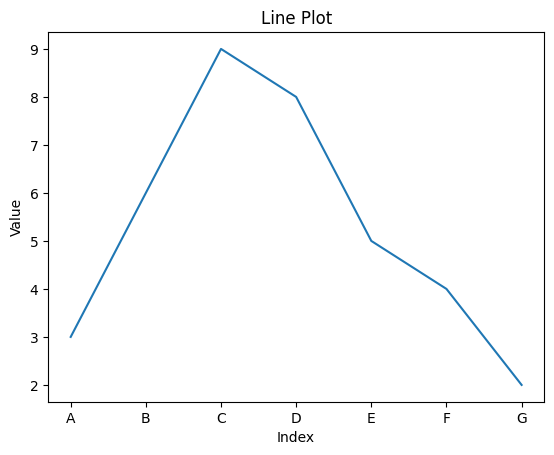

In [ ]:
s = pd.Series([3, 6, 9, 8, 5, 4, 2], index=list('ABCDEFG'))
ax = s.plot(kind='line', title='Line Plot')
ax.set_xlabel('Index')
ax.set_ylabel('Value')
plt.show()

### Bar chart

Bar charts are suitable for comparing categories.

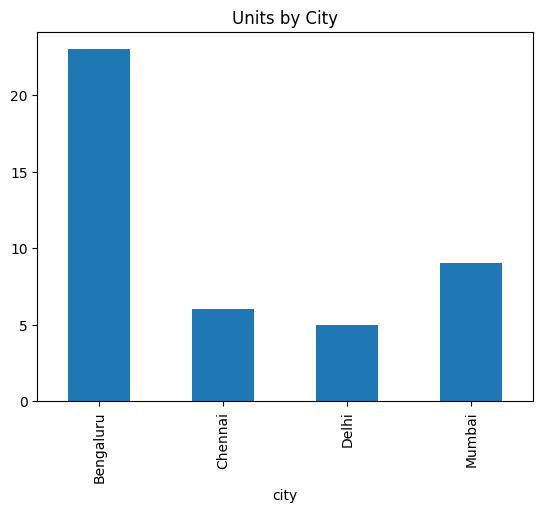

In [ ]:
sales.groupby('city')['quantity'].sum().plot(kind='bar', title='Units by City')
plt.show()

### Horizontal bar chart

Horizontal bars are useful when category labels are longer.

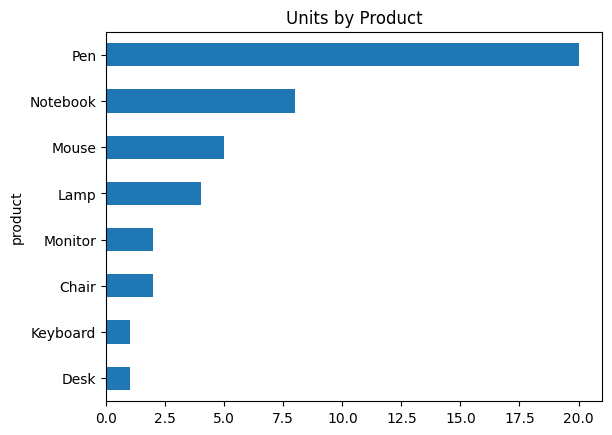

In [ ]:
sales.groupby('product')['quantity'].sum().sort_values().plot(kind='barh', title='Units by Product')
plt.show()

### Histogram

Histograms show the distribution of numeric values.

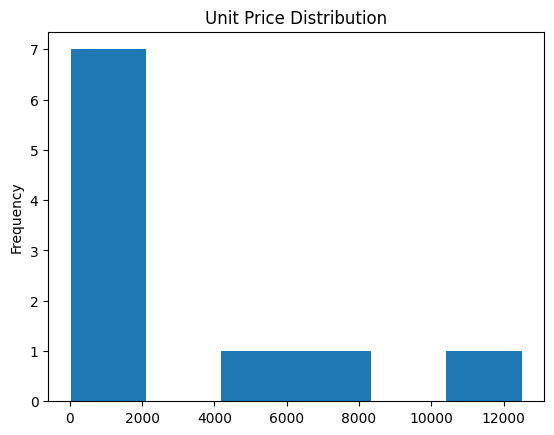

In [ ]:
sales['unit_price'].plot(kind='hist', bins=6, title='Unit Price Distribution')
plt.show()

### Box plot

Box plots summarize spread and can reveal potential outliers.

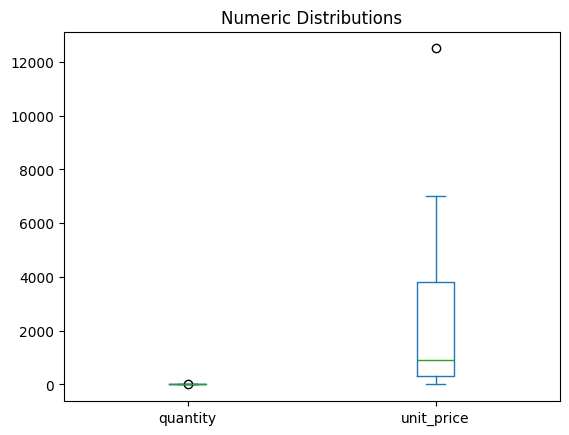

In [ ]:
sales[['quantity', 'unit_price']].plot(kind='box', title='Numeric Distributions')
plt.show()

### Pie chart

Pie charts can show simple composition, though bars are often easier to compare precisely.

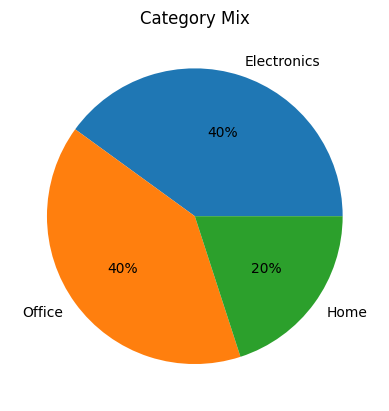

In [ ]:
sales['category'].value_counts().plot(kind='pie', autopct='%1.0f%%', title='Category Mix')
plt.ylabel('')
plt.show()

### Area plot

Area charts emphasize totals or cumulative-looking patterns over an ordered axis.

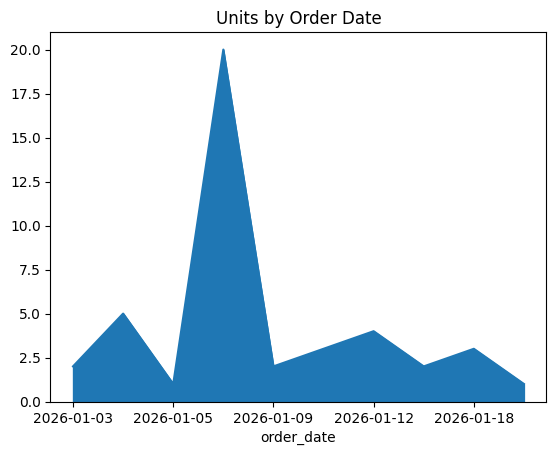

In [ ]:
series = sales.groupby('order_date')['quantity'].sum().sort_index()
series.plot(kind='area', title='Units by Order Date')
plt.show()

### KDE/density plot

A KDE provides a smoothed view of a numeric distribution.

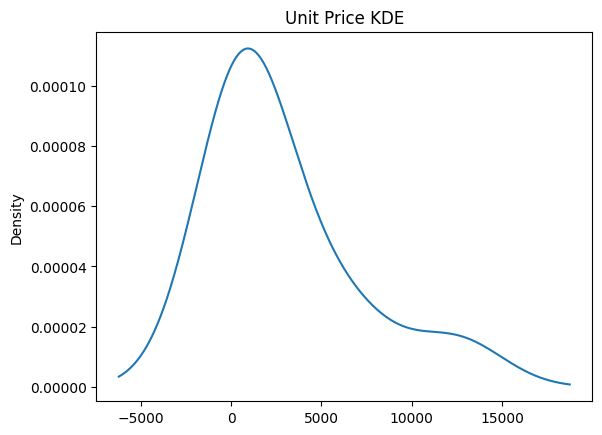

In [ ]:
sales['unit_price'].plot(kind='kde', title='Unit Price KDE')
plt.show()

# 2️⃣3️⃣ File Handling: CSV, TSV, Excel, JSON

The supplied reference includes reading/writing CSV or Excel and controlling read options such as index columns, skipped rows, classification, correlation, and skew. fileciteturn4file0L98-L105

### Read CSV

The simplest form is `pd.read_csv(path)`.

In [ ]:
df = pd.read_csv(RAW / 'sales.csv')
print(df.head())

   order_id  order_date customer  ... unit_price discount payment
0      1001  2026-01-03     Asha  ...        900     0.05    Card
1      1002  2026-01-04     Ravi  ...        120     0.00     UPI
2      1003  2026-01-05     Neha  ...       1800     0.10    Card
3      1004  2026-01-07     Amit  ...         25     0.02    Cash
4      1005  2026-01-09     Riya  ...      12500     0.08     UPI

[5 rows x 10 columns]


### Read TSV

Tab-separated files are part of the CSV family; specify `sep='\t'`.

In [ ]:
tsv = 'id\tname\tamount\n1\tRavi\t100\n2\tAsha\t200\n'
(RAW/'sample.tsv').write_text(tsv, encoding='utf-8')
print(pd.read_csv(RAW/'sample.tsv', sep='\t'))

   id  name  amount
0   1  Ravi     100
1   2  Asha     200


### Read selected columns

`usecols` limits the columns read into memory.

In [ ]:
print(pd.read_csv(RAW/'sales.csv', usecols=['order_id', 'city', 'quantity']))

   order_id       city  quantity
0      1001      Delhi         2
1      1002     Mumbai         5
2      1003      Delhi         1
3      1004  Bengaluru        20
4      1005    Chennai         2
5      1006     Mumbai         3
6      1007    Chennai         4
7      1008      Delhi         2
8      1009  Bengaluru         3
9      1010     Mumbai         1


### Read only a sample

`nrows` is useful while developing a pipeline against large files.

In [ ]:
print(pd.read_csv(RAW/'sales.csv', nrows=3))

   order_id  order_date customer  ... unit_price discount payment
0      1001  2026-01-03     Asha  ...        900     0.05    Card
1      1002  2026-01-04     Ravi  ...        120     0.00     UPI
2      1003  2026-01-05     Neha  ...       1800     0.10    Card

[3 rows x 10 columns]


### Skip rows

`skiprows` can ignore metadata/header noise in messy exports.

In [ ]:
messy = 'REPORT\nGenerated: 2026-01-01\ncity,value\nDelhi,10\nMumbai,20\n'
(RAW/'messy.csv').write_text(messy, encoding='utf-8')
print(pd.read_csv(RAW/'messy.csv', skiprows=2))

     city  value
0   Delhi     10
1  Mumbai     20


### Custom column names

Use `header=None` with `names=[...]` when the source has no header row.

In [ ]:
(RAW/'no_header.csv').write_text('1,Alice,100\n2,Bob,200\n', encoding='utf-8')
print(pd.read_csv(RAW/'no_header.csv', header=None, names=['id', 'name', 'amount']))

   id   name  amount
0   1  Alice     100
1   2    Bob     200


### Index column

`index_col` sets one column as the DataFrame index during loading.

In [ ]:
df = pd.read_csv(RAW/'sales.csv', index_col='order_id')
print(df.head())

          order_date customer       city  ... unit_price discount  payment
order_id                                  ...                             
1001      2026-01-03     Asha      Delhi  ...        900     0.05     Card
1002      2026-01-04     Ravi     Mumbai  ...        120     0.00      UPI
1003      2026-01-05     Neha      Delhi  ...       1800     0.10     Card
1004      2026-01-07     Amit  Bengaluru  ...         25     0.02     Cash
1005      2026-01-09     Riya    Chennai  ...      12500     0.08      UPI

[5 rows x 9 columns]


### Control dtype on load

Identifiers such as `00123` should usually be read as strings to preserve leading zeros.

In [ ]:
(RAW/'ids.csv').write_text('customer_id,amount\n00123,100\n00124,200\n', encoding='utf-8')
df = pd.read_csv(RAW/'ids.csv', dtype={'customer_id': 'string'})
print(df)
print(df.dtypes)

  customer_id  amount
0       00123     100
1       00124     200
customer_id    string[python]
amount                  int64
dtype: object


### Missing-value markers on read

Use `na_values` to map custom source markers to missing values.

In [ ]:
(RAW/'missing_markers.csv').write_text('id,value\n1,NA\n2,100\n3,-\n', encoding='utf-8')
print(pd.read_csv(RAW/'missing_markers.csv', na_values=['NA', '-']))

   id  value
0   1    NaN
1   2  100.0
2   3    NaN


### Date parsing on read

Datetime columns can be parsed during ingestion.

In [ ]:
df = pd.read_csv(RAW/'sales.csv', parse_dates=['order_date'])
print(df.dtypes)

order_id               int64
order_date    datetime64[ns]
customer              object
city                  object
category              object
product               object
quantity               int64
unit_price             int64
discount             float64
payment               object
dtype: object


### skipinitialspace

This option handles spaces after delimiters in common hand-edited CSVs.

In [ ]:
(RAW/'spaces.csv').write_text('id, name, city\n1, Ravi, Delhi\n2, Asha, Mumbai\n', encoding='utf-8')
print(pd.read_csv(RAW/'spaces.csv', skipinitialspace=True))

   id  name    city
0   1  Ravi   Delhi
1   2  Asha  Mumbai


### Comment lines

Lines beginning with a chosen marker can be ignored.

In [ ]:
(RAW/'comments.csv').write_text('# metadata\nid,value\n1,10\n2,20\n', encoding='utf-8')
print(pd.read_csv(RAW/'comments.csv', comment='#'))

   id  value
0   1     10
1   2     20


### Read Excel

`read_excel` requires an engine such as `openpyxl`. This cell demonstrates the call against a file created locally later in the notebook.

In [ ]:
excel_path = OUTPUT / 'sales_demo.xlsx'
sales.head().to_excel(excel_path, index=False)
print(pd.read_excel(excel_path).head())

   order_id  order_date customer  ... unit_price discount payment
0      1001  2026-01-03     Asha  ...        900     0.05    Card
1      1002  2026-01-04     Ravi  ...        120     0.00     UPI
2      1003  2026-01-05     Neha  ...       1800     0.10    Card
3      1004  2026-01-07     Amit  ...         25     0.02    Cash
4      1005  2026-01-09     Riya  ...      12500     0.08     UPI

[5 rows x 10 columns]


### Read JSON

Pandas can read JSON records and other supported JSON structures.

In [ ]:
json_path = OUTPUT / 'sample.json'
json_path.write_text('[{"id":1,"name":"Asha"},{"id":2,"name":"Ravi"}]', encoding='utf-8')
print(pd.read_json(json_path))

   id  name
0   1  Asha
1   2  Ravi


# 2️⃣4️⃣ Exporting & Saving Data

Export only after validation and transformation. Include `index=False` when the DataFrame index is not meant to become a CSV column.

### Write CSV

`to_csv` exports a DataFrame to CSV.

In [ ]:
clean = sales.copy()
clean['discount'] = clean['discount'].fillna(0)
out_csv = OUTPUT / 'cleaned_sales.csv'
clean.to_csv(out_csv, index=False)
print(out_csv.resolve())

/mnt/data/.pandas_lab/output/cleaned_sales.csv


### Write Excel

`to_excel` exports tabular data to `.xlsx`.

In [ ]:
out_xlsx = OUTPUT / 'cleaned_sales.xlsx'
clean.to_excel(out_xlsx, index=False)
print(out_xlsx.resolve())

/mnt/data/.pandas_lab/output/cleaned_sales.xlsx


### Write selected columns

Use `columns=[...]` to control what gets exported.

In [ ]:
sales.to_csv(OUTPUT/'sales_subset.csv', index=False, columns=['order_id', 'city', 'quantity'])
print(pd.read_csv(OUTPUT/'sales_subset.csv').head())

   order_id       city  quantity
0      1001      Delhi         2
1      1002     Mumbai         5
2      1003      Delhi         1
3      1004  Bengaluru        20
4      1005    Chennai         2


### Write with missing-value representation

`na_rep` controls how missing values are written.

In [ ]:
df = pd.DataFrame({'A': [1, None], 'B': ['x', 'y']})
df.to_csv(OUTPUT/'na_rep_demo.csv', index=False, na_rep='NA')
print((OUTPUT/'na_rep_demo.csv').read_text())

A,B
1.0,x
NA,y



### Compressed CSV

Pandas supports compressed CSVs such as gzip.

In [ ]:
path = OUTPUT / 'sales.csv.gz'
sales.to_csv(path, index=False, compression='gzip')
print(pd.read_csv(path).head())

   order_id  order_date customer  ... unit_price discount payment
0      1001  2026-01-03     Asha  ...        900     0.05    Card
1      1002  2026-01-04     Ravi  ...        120     0.00     UPI
2      1003  2026-01-05     Neha  ...       1800     0.10    Card
3      1004  2026-01-07     Amit  ...         25     0.02    Cash
4      1005  2026-01-09     Riya  ...      12500     0.08     UPI

[5 rows x 10 columns]


# 2️⃣5️⃣ Advanced CSV Ingestion

Robust ingestion means controlling parsing, types, missing values, encoding, bad rows, and scale.

### Converters

A converter function can normalize a column while reading.

In [ ]:
(RAW/'currency.csv').write_text('id,price\n1,"$1,200"\n2,"$2,500"\n', encoding='utf-8')

def clean_currency(x):
    x = str(x).replace('$', '').replace(',', '')
    return float(x)

print(pd.read_csv(RAW/'currency.csv', converters={'price': clean_currency}))

   id   price
0   1  1200.0
1   2  2500.0


### Bad lines

Use `on_bad_lines='warn'` or a callable when you need controlled handling of malformed records.

In [ ]:
(RAW/'bad_lines.csv').write_text('id,name\n1,Asha\n2,Bad,Extra\n3,Ravi\n', encoding='utf-8')
print(pd.read_csv(RAW/'bad_lines.csv', on_bad_lines='warn'))

   id  name
0   1  Asha
1   3  Ravi


/tmp/ipykernel_477/754809473.py:2: ParserWarning: Skipping line 3: expected 2 fields, saw 3

  print(pd.read_csv(RAW/'bad_lines.csv', on_bad_lines='warn'))


### Chunked reading

`chunksize` yields DataFrame chunks instead of loading the whole file at once.

In [ ]:
total_units = 0
for chunk in pd.read_csv(RAW/'sales.csv', chunksize=3):
    total_units += chunk['quantity'].sum()
print('Total units:', total_units)

Total units: 43


### Chunked aggregation pattern

This pattern scales to files much larger than available RAM.

In [ ]:
totals = []
for chunk in pd.read_csv(RAW/'sales.csv', chunksize=3):
    totals.append(chunk.groupby('city')['quantity'].sum())
result = pd.concat(totals).groupby(level=0).sum().sort_values(ascending=False)
print(result)

city
Bengaluru    23
Mumbai        9
Chennai       6
Delhi         5
Name: quantity, dtype: int64


### Read from StringIO

Pandas can parse in-memory text using `io.StringIO`.

In [ ]:
from io import StringIO
text = 'a,b\n1,2\n3,4\n'
print(pd.read_csv(StringIO(text)))

   a  b
0  1  2
1  3  4


### Read from a URL

`read_csv` can read from URLs when the environment permits network access; this notebook deliberately does not depend on network access.

In [ ]:
print('Example only: pd.read_csv("https://example.com/data.csv")')

Example only: pd.read_csv("https://example.com/data.csv")


# 2️⃣6️⃣ Data Types, Memory & Performance

Correct types are a data-quality tool as well as a performance tool.

### Inspect dtypes

Pandas may infer numeric, datetime, boolean, object/string, and category types.

In [ ]:
print(sales.dtypes)

order_id        int64
order_date     object
customer       object
city           object
category       object
product        object
quantity        int64
unit_price      int64
discount      float64
payment        object
dtype: object


### Convert types

Use `astype` for explicit conversions when the data supports them.

In [ ]:
df = sales.copy()
df['quantity'] = df['quantity'].astype('int64')
print(df.dtypes)

order_id        int64
order_date     object
customer       object
city           object
category       object
product        object
quantity        int64
unit_price      int64
discount      float64
payment        object
dtype: object


### Nullable integer

Pandas nullable dtypes allow missing values while retaining integer semantics.

In [ ]:
s = pd.Series([1, 2, None], dtype='Int64')
print(s)
print(s.dtype)

0       1
1       2
2    <NA>
dtype: Int64
Int64


### Nullable boolean

The nullable boolean dtype can represent True, False, and missing.

In [ ]:
s = pd.Series([True, False, None], dtype='boolean')
print(s)
print(s.dtype)

0     True
1    False
2     <NA>
dtype: boolean
boolean


### Category for low-cardinality text

Categoricals can reduce memory and make category semantics explicit.

In [ ]:
df = pd.DataFrame({'city': ['Delhi', 'Mumbai', 'Delhi', 'Mumbai', 'Delhi']})
before = df.memory_usage(deep=True).sum()
df['city'] = df['city'].astype('category')
after = df.memory_usage(deep=True).sum()
print('before:', before, 'bytes')
print('after :', after, 'bytes')
print(df.dtypes)

before: 404 bytes
after : 354 bytes
city    category
dtype: object


### Downcast numeric columns

Downcasting can reduce memory for large numeric columns when ranges permit.

In [ ]:
s = pd.Series([1, 2, 3, 1000])
print(pd.to_numeric(s, downcast='integer').dtype)

int16


### Use vectorization instead of Python loops

Vectorized expressions are generally clearer and faster than row-by-row loops for column calculations.

In [ ]:
df = sales.copy()
loop_result = [q * p for q, p in zip(df['quantity'], df['unit_price'])]
vector_result = (df['quantity'] * df['unit_price']).tolist()
print(loop_result == vector_result)

True


# 2️⃣7️⃣ Method Chaining & Production-Style Workflows

Method chaining keeps transformations readable, testable, and close to the business logic.

### Simple chain

Use `query`, `assign`, `loc`, and `sort_values` in a sequence.

In [ ]:
result = (sales
    .query('quantity >= 2')
    .assign(gross=lambda d: d['quantity'] * d['unit_price'])
    .loc[:, ['order_id', 'city', 'gross']]
    .sort_values('gross', ascending=False))
print(result)

   order_id       city  gross
4      1005    Chennai  25000
7      1008      Delhi   9000
6      1007    Chennai   3400
8      1009  Bengaluru   2700
0      1001      Delhi   1800
1      1002     Mumbai    600
3      1004  Bengaluru    500
5      1006     Mumbai    360


### pipe

`pipe` lets you insert reusable functions into a chain.

In [ ]:
def add_net_sales(df):
    out = df.copy()
    out['gross'] = out['quantity'] * out['unit_price']
    out['net'] = out['gross'] * (1 - out['discount'].fillna(0))
    return out

result = sales.pipe(add_net_sales)
print(result[['order_id', 'gross', 'net']].head())

   order_id  gross      net
0      1001   1800   1710.0
1      1002    600    600.0
2      1003   1800   1620.0
3      1004    500    490.0
4      1005  25000  23000.0


### Avoid chained assignment

Create an explicit copy when you intend to modify a filtered result.

In [ ]:
filtered = sales.loc[sales['city'].eq('Delhi')].copy()
filtered['flag'] = True
print(filtered[['order_id', 'flag']])

   order_id  flag
0      1001  True
2      1003  True
7      1008  True


### Copy vs reference

Assignment creates another reference to the same DataFrame; `.copy()` creates an independent object.

In [ ]:
a = sales[['order_id', 'city']]
b = a
c = a.copy()
b.loc[b.index[0], 'city'] = 'TEST'
print('a changed by alias:', a.loc[a.index[0], 'city'])
print('c independent    :', c.loc[c.index[0], 'city'])

a changed by alias: TEST
c independent    : Delhi


# 2️⃣8️⃣ Validation, Reproducibility & Common Pitfalls

A reliable analytics workflow validates assumptions before analysis and export.

### Validate required columns

Schema validation catches broken inputs early.

In [ ]:
required = {'order_id', 'order_date', 'city', 'quantity', 'unit_price'}
missing = required - set(sales.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
print('Schema OK')

Schema OK


### Check uniqueness

Identifiers should be unique when the business rule says they are.

In [ ]:
print('Unique order IDs:', sales['order_id'].is_unique)

Unique order IDs: True


### Check ranges

Domain rules can be expressed as assertions.

In [ ]:
assert (sales['quantity'] > 0).all()
assert (sales['unit_price'] > 0).all()
assert sales['discount'].dropna().between(0, 1).all()
print('Range checks passed')

Range checks passed


### Check duplicate business keys

A business key may span more than one column.

In [ ]:
dupes = sales.duplicated(subset=['customer', 'order_date', 'product'])
print('duplicate business-key rows:', int(dupes.sum()))

duplicate business-key rows: 0


### Random state for reproducibility

Use `random_state` when sampling and testing so results can be reproduced.

In [ ]:
print(sales.sample(3, random_state=42))

   order_id  order_date customer  ... unit_price discount payment
8      1009  2026-01-18    Meera  ...        900      0.0     UPI
1      1002  2026-01-04     Ravi  ...        120      0.0     UPI
5      1006  2026-01-10    Karan  ...        120      NaN     UPI

[3 rows x 10 columns]


### Common pitfall: Python `and` vs Pandas `&`

Use `&`/`|` for element-wise boolean logic and wrap each comparison in parentheses.

In [ ]:
mask = (sales['quantity'] >= 2) & (sales['unit_price'] > 1000)
print(sales.loc[mask, ['order_id', 'quantity', 'unit_price']])

   order_id  quantity  unit_price
4      1005         2       12500
7      1008         2        4500


### Common pitfall: column selection

One set of brackets returns a Series; double brackets return a DataFrame.

In [ ]:
print(type(sales['city']).__name__)
print(type(sales[['city']]).__name__)

Series
DataFrame


### Common pitfall: missing values are not equal

Use `isna()` instead of `== np.nan` when checking for missing values.

In [ ]:
s = pd.Series([1, np.nan, 3])
print('isna:', s.isna().tolist())

isna: [False, True, False]


# 2️⃣9️⃣ End-to-End Analytics Projects

These projects combine ingestion, cleaning, transformation, aggregation, validation, and export.

### Project 1 — Sales summary

Goal: calculate gross and net sales, then summarize by city and category.

In [ ]:
df = pd.read_csv(RAW/'sales.csv', parse_dates=['order_date'])
df['discount'] = df['discount'].fillna(0)
df['gross'] = df['quantity'] * df['unit_price']
df['net_sales'] = df['gross'] * (1 - df['discount'])
summary = (df.groupby(['city', 'category'], as_index=False)
             .agg(orders=('order_id', 'count'),
                  units=('quantity', 'sum'),
                  gross_sales=('gross', 'sum'),
                  net_sales=('net_sales', 'sum'))
             .sort_values('net_sales', ascending=False))
print(summary)

        city     category  orders  units  gross_sales  net_sales
2    Chennai  Electronics       1      2        25000    23000.0
5      Delhi         Home       1      2         9000     8550.0
6     Mumbai       Office       3      9         7960     7610.0
4      Delhi  Electronics       2      3         3600     3330.0
3    Chennai         Home       1      4         3400     2890.0
0  Bengaluru  Electronics       1      3         2700     2700.0
1  Bengaluru       Office       1     20          500      490.0


### Project 2 — Customer enrichment

Goal: join order data to customer attributes.

In [ ]:
orders = pd.read_csv(RAW/'sales.csv')
customers = pd.read_csv(RAW/'customers.csv')
# Map names to a simple customer key for this practice dataset.
name_to_id = dict(zip(customers['customer'], customers['customer_id']))
orders['customer_id'] = orders['customer'].map(name_to_id)
enriched = orders.merge(customers, on=['customer_id', 'customer', 'city'], how='left', validate='many_to_one')
print(enriched[['order_id', 'customer_id', 'customer', 'segment']].head())

   order_id customer_id customer    segment
0      1001        C001     Asha   Consumer
1      1002        C002     Ravi  Corporate
2      1003        C003     Neha   Consumer
3      1004        C004     Amit  Corporate
4      1005        C005     Riya   Consumer


### Project 3 — Monthly KPI table

Goal: create a time-based summary by month.

In [ ]:
df = pd.read_csv(RAW/'sales.csv', parse_dates=['order_date'])
df['gross'] = df['quantity'] * df['unit_price']
df['month'] = df['order_date'].dt.to_period('M')
kpi = df.groupby('month', as_index=False).agg(orders=('order_id', 'count'), units=('quantity', 'sum'), revenue=('gross', 'sum'))
print(kpi)

     month  orders  units  revenue
0  2026-01      10     43    52160


### Project 4 — Top products

Goal: rank products by net sales and keep the top five.

In [ ]:
df = pd.read_csv(RAW/'sales.csv')
df['discount'] = df['discount'].fillna(0)
df['net_sales'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])
top5 = (df.groupby('product', as_index=False)['net_sales'].sum()
          .sort_values('net_sales', ascending=False)
          .head(5))
print(top5)

   product  net_sales
4  Monitor    23000.0
0    Chair     8550.0
1     Desk     6650.0
5    Mouse     4410.0
3     Lamp     2890.0


### Project 5 — Data quality report

Goal: produce row count, duplicate count, null count, and type information for auditability.

In [ ]:
df = pd.read_csv(RAW/'sales.csv')
quality = pd.DataFrame({
    'rows': [len(df)],
    'columns': [df.shape[1]],
    'duplicate_rows': [int(df.duplicated().sum())],
    'missing_cells': [int(df.isna().sum().sum())],
    'memory_bytes': [int(df.memory_usage(deep=True).sum())]
})
print(quality)
print('Missing by column:\n', df.isna().sum())

   rows  columns  duplicate_rows  missing_cells  memory_bytes
0    10       10               0              1          3770
Missing by column:
 order_id      0
order_date    0
customer      0
city          0
category      0
product       0
quantity      0
unit_price    0
discount      1
payment       0
dtype: int64


### Project 6 — Chunked file profile

Goal: profile a file without reading all rows at once.

In [ ]:
profiles = []
for i, chunk in enumerate(pd.read_csv(RAW/'sales.csv', chunksize=4), start=1):
    profiles.append({
        'chunk': i,
        'rows': len(chunk),
        'units': chunk['quantity'].sum(),
        'revenue': (chunk['quantity'] * chunk['unit_price']).sum()
    })
print(pd.DataFrame(profiles))

   chunk  rows  units  revenue
0      1     4     28     4700
1      2     4     11    37760
2      3     2      4     9700


### Project 7 — Final cleaned export

Goal: validate, clean, calculate, and export an analysis-ready dataset.

In [ ]:
df = pd.read_csv(RAW/'sales.csv', parse_dates=['order_date'])
required = {'order_id','order_date','customer','city','category','product','quantity','unit_price','discount','payment'}
missing_cols = required - set(df.columns)
if missing_cols:
    raise ValueError(f'Missing columns: {missing_cols}')
df['discount'] = df['discount'].fillna(0)
df['gross_sales'] = df['quantity'] * df['unit_price']
df['net_sales'] = df['gross_sales'] * (1 - df['discount'])
df = df.drop_duplicates().sort_values('order_date')
out = PROCESSED / 'sales_analysis_ready.csv'
df.to_csv(out, index=False)
print('Exported:', out.resolve())

Exported: /mnt/data/.pandas_lab/data/processed/sales_analysis_ready.csv


# 3️⃣0️⃣ Practice Exercises

Try the exercises without looking at earlier cells. Suggested answers are intentionally omitted so this section can be used for self-study.

### Exercise 1

**Task:** Load `sales.csv` and return only orders from Chennai.

**Hint:** Use `read_csv` and boolean filtering.

### Exercise 2

**Task:** Find the top three products by total quantity sold.

**Hint:** Group by product, sum quantity, sort descending, head(3).

### Exercise 3

**Task:** Calculate net sales using quantity, unit price, and discount.

**Hint:** Create a vectorized calculated column.

### Exercise 4

**Task:** Find cities with average unit price above 3000.

**Hint:** Group by city, compute mean, then filter.

### Exercise 5

**Task:** Create a pivot table of quantity by city and category.

**Hint:** Use `pivot_table` with `aggfunc="sum"`.

### Exercise 6

**Task:** Join the orders with customer segment information.

**Hint:** Create a common key and use `merge`.

### Exercise 7

**Task:** Create a monthly revenue DataFrame.

**Hint:** Convert to datetime and use `.dt.to_period("M")` or resample.

### Exercise 8

**Task:** Identify columns with missing values and report percentages.

**Hint:** Use `isna().mean()`.

### Exercise 9

**Task:** Preserve leading zeros when loading customer IDs.

**Hint:** Use `dtype={...: "string"}`.

### Exercise 10

**Task:** Read the sales file in chunks and calculate total units.

**Hint:** Use `chunksize` and accumulate the sum.

### Exercise 11

**Task:** Create a category with ordered values Bronze < Silver < Gold.

**Hint:** Use `pd.Categorical(..., ordered=True)`.

### Exercise 12

**Task:** Create a three-level MultiIndex example and unstack one level.

**Hint:** Use `MultiIndex.from_product`.

# 🧾 Quick Reference

Use this section for revision after completing the notebook.

| Task | Common Pandas expression |
|---|---|
| Create Series | `pd.Series(...)` |
| Create DataFrame | `pd.DataFrame(...)` |
| Read CSV | `pd.read_csv(...)` |
| Write CSV | `df.to_csv(...)` |
| Read Excel | `pd.read_excel(...)` |
| Write Excel | `df.to_excel(...)` |
| Inspect top rows | `df.head()` |
| Inspect structure | `df.info()` |
| Summary stats | `df.describe()` |
| Select one column | `df['col']` |
| Select many columns | `df[['a','b']]` |
| Position-based selection | `df.iloc[...]` |
| Label-based selection | `df.loc[...]` |
| Filter rows | `df[mask]` |
| Query rows | `df.query(...)` |
| Sort values | `df.sort_values(...)` |
| Rename | `df.rename(...)` |
| Drop | `df.drop(...)` |
| Missing count | `df.isna().sum()` |
| Fill missing | `df.fillna(...)` |
| Remove duplicates | `df.drop_duplicates()` |
| Group | `df.groupby(...)` |
| Concatenate | `pd.concat([...])` |
| Merge | `pd.merge(...)` |
| Reshape wide | `df.pivot(...)` / `pivot_table(...)` |
| Reshape long | `df.melt(...)` |
| Datetime parsing | `pd.to_datetime(...)` |
| Rolling window | `s.rolling(...)` |
| Categorical type | `s.astype('category')` |
| Export compressed CSV | `df.to_csv(..., compression='gzip')` |
| Chunked reading | `pd.read_csv(..., chunksize=...)` |

## ✅ Recommended Learning Sequence

1. Series and Index  
2. DataFrame creation and inspection  
3. Column/row selection with `loc` and `iloc`  
4. Filtering and sorting  
5. Missing data and cleaning  
6. GroupBy and aggregation  
7. Merge/concat/join  
8. Reshaping and MultiIndex  
9. Strings and datetimes  
10. Visualization  
11. File ingestion/export  
12. Performance, validation, and end-to-end projects

The supplied reference follows a closely related path from Series and basic DataFrame operations into concatenation/merging, advanced operations, missing-data handling, MultiIndex, strings, dates, and CSV/Excel handling. fileciteturn4file0L7-L25 fileciteturn4file0L47-L105